## PART 1A. Load Dataset

In [29]:
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer

# Dataset path
csv_path = "/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv"

df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head(10))

Dataset loaded successfully!
Shape: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


## PART 1B. Identify features and target variable

In [30]:
print("Columns in the dataset:")
print(df.columns.tolist())

target_col = "Major_Category"

print("Target variable:", target_col)

features = [col for col in df.columns if col != target_col]
print("Number of features:", len(features))
print("Features:", features)

Columns in the dataset:
['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']
Target variable: Major_Category
Number of features: 15
Features: ['Student_ID', 'Year_of_Study', 'Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score', 'Burnout_Risk_Level']


## PART 1C. Exploratory Data Analysis

In [31]:
# Dataset information
display(df.info())

# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values)

# Summary statistics
display(df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

None

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
count,50000.000000,50000,50000,50000.000000,50000.000000,50000,50000,50000.00000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000
unique,NaN,5,5,NaN,NaN,5,3,NaN,2,NaN,NaN,3,NaN,NaN,NaN,3
top,NaN,STEM,Junior,NaN,NaN,Debugging/Troubleshooting,Beginner,NaN,False,NaN,NaN,Allowed_With_Citation,NaN,NaN,NaN,Medium
freq,NaN,15059,11045,NaN,NaN,12295,18495,NaN,28846,NaN,NaN,25224,NaN,NaN,NaN,21144
mean,125000.500000,NaN,NaN,3.146102,8.427752,NaN,NaN,2.80026,NaN,11.209271,3.505360,NaN,4.270760,3.349299,75.798125,NaN
std,14433.901067,NaN,NaN,0.478854,8.269490,NaN,NaN,1.18802,NaN,5.156426,1.820812,NaN,2.144066,0.495673,13.281626,NaN
min,100001.000000,NaN,NaN,1.183000,0.000000,NaN,NaN,1.00000,NaN,1.000000,1.000000,NaN,1.000000,1.000000,10.780000,NaN
25%,112500.750000,NaN,NaN,2.834000,2.390000,NaN,NaN,2.00000,NaN,7.560000,2.000000,NaN,3.000000,3.023750,66.820000,NaN
50%,125000.500000,NaN,NaN,3.210000,5.800000,NaN,NaN,3.00000,NaN,11.180000,3.000000,NaN,4.000000,3.421000,76.000000,NaN
75%,137500.250000,NaN,NaN,3.521000,11.720000,NaN,NaN,4.00000,NaN,14.710000,5.000000,NaN,6.000000,3.749000,85.190000,NaN


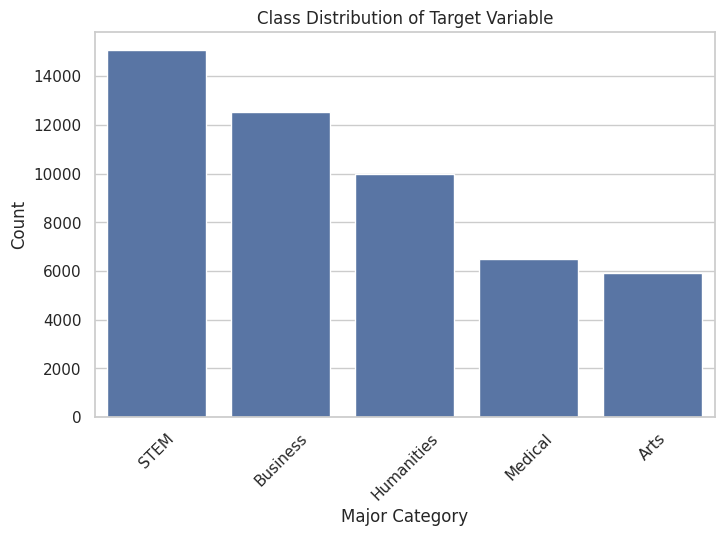

In [32]:
# CLASS DISTRIBUTION
plt.figure(figsize=(8, 5))
sns.countplot(x=target_col, data=df, order=df[target_col].value_counts().index)
plt.title("Class Distribution of Target Variable")
plt.xlabel("Major Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

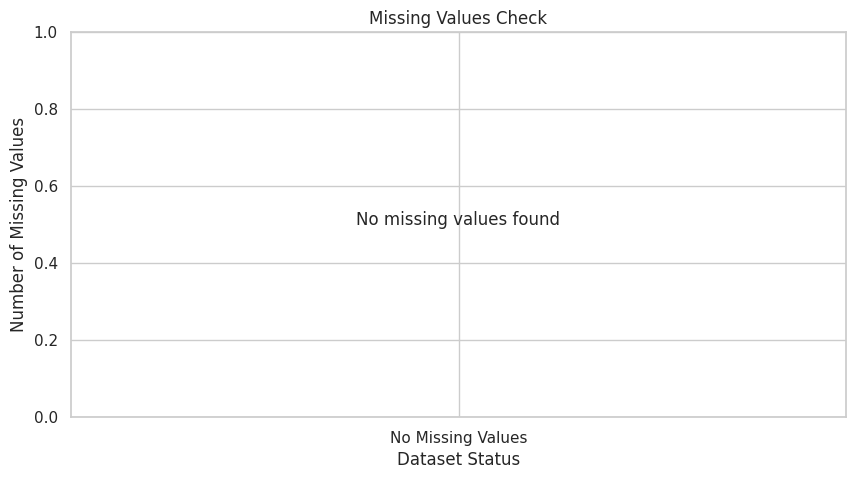

In [35]:
# MISSING VALUES
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values)

missing_nonzero = missing_values[missing_values > 0]

plt.figure(figsize=(10, 5))

if missing_nonzero.empty:
    plt.bar(["No Missing Values"], [0])
    plt.title("Missing Values Check")
    plt.xlabel("Dataset Status")
    plt.ylabel("Number of Missing Values")
    plt.ylim(0, 1)
    plt.text(0, 0.5, "No missing values found", ha="center", fontsize=12)
else:
    missing_nonzero.plot(kind="bar")
    plt.title("Missing Values per Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)

plt.show()

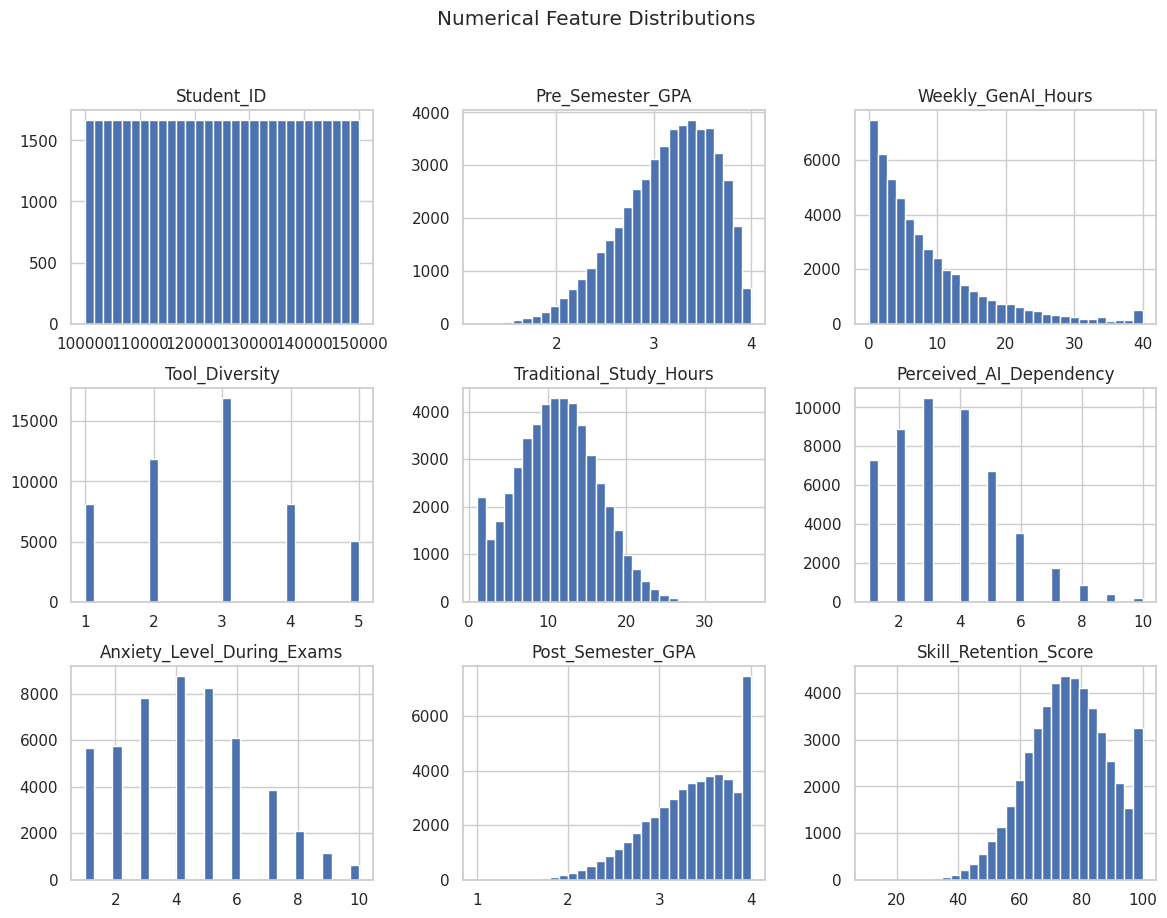

In [36]:
# NUMERICAL FEATURE DISTRIBUTIONS
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.show()

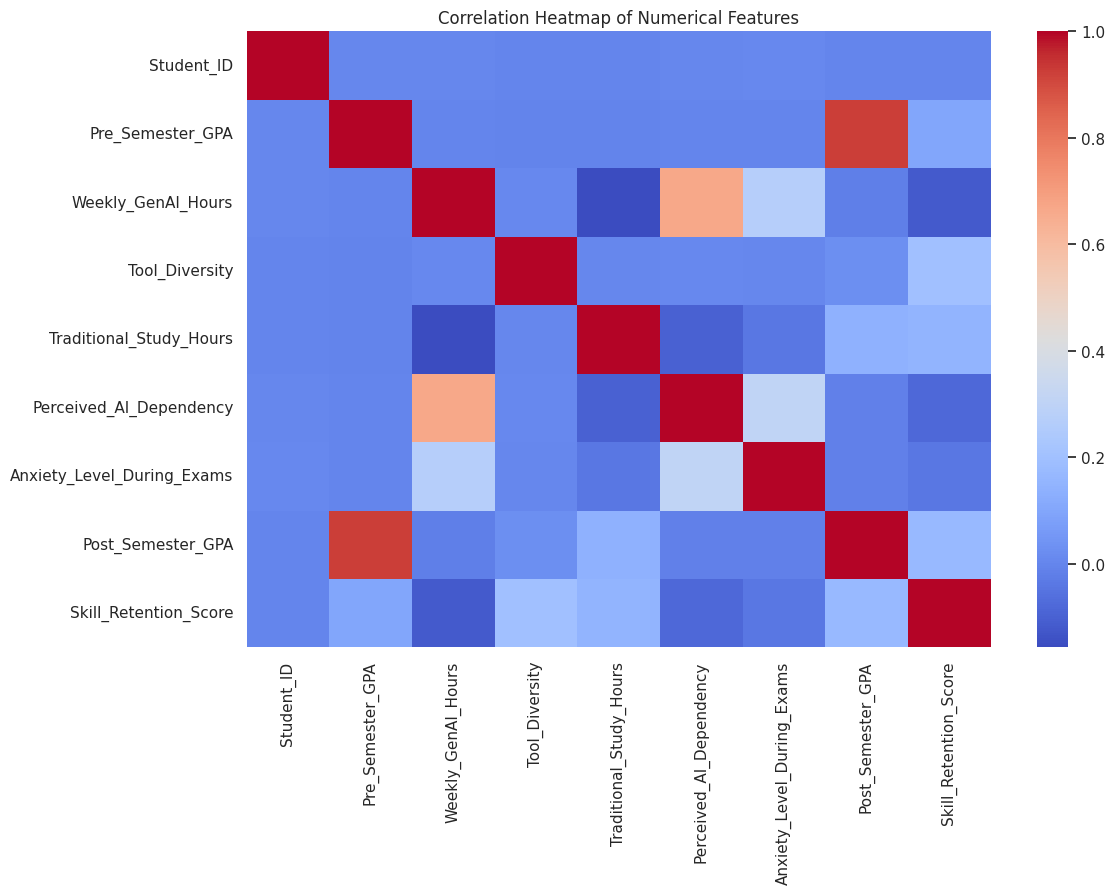

In [37]:
#CORRELATION HEATMAP
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

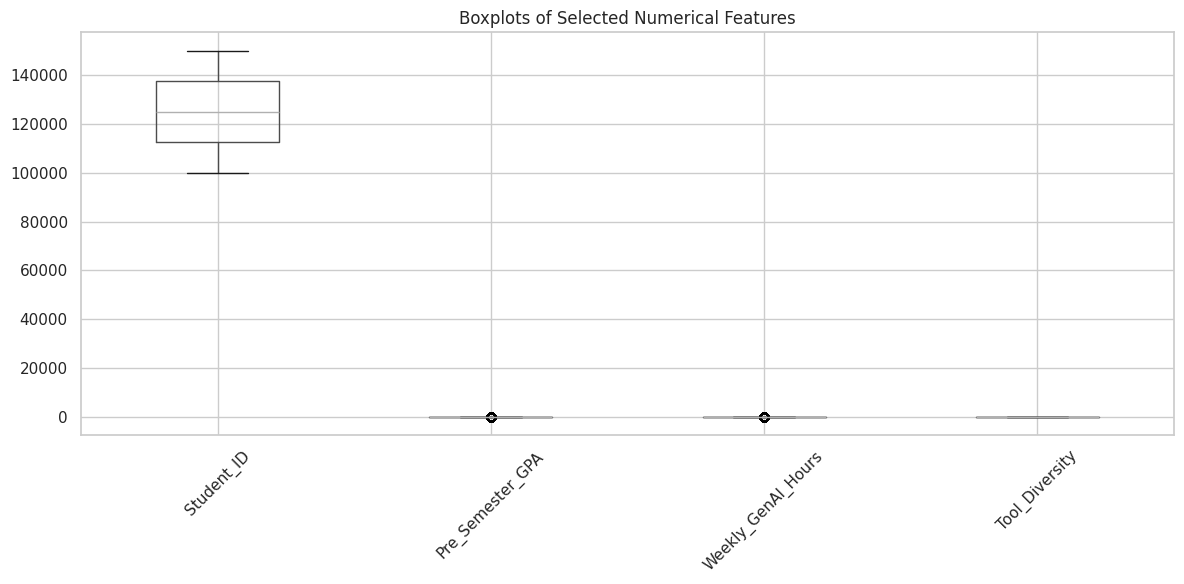

In [49]:
# BOXPLOT FOR NUMERIC FEATURES 
top_numeric = numeric_cols[:4]

if len(top_numeric) > 0:
    plt.figure(figsize=(12, 6))
    df[top_numeric].boxplot()
    plt.title("Boxplots of Selected Numerical Features")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found for boxplot.")

## PART 1D. PREPROCESS THE DATA 

In [38]:
# Remove ID columns if present because they are identifiers, not useful features
id_cols = [col for col in df.columns if "id" in col.lower()]

df_model = df.drop(columns=id_cols, errors="ignore").copy()
df_model = df_model.dropna(subset=[target_col])

X = df_model.drop(columns=[target_col])
y = df_model[target_col].astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

X shape: (50000, 13)
y shape: (50000,)
Numerical features: ['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']
Categorical features: ['Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


## PART 2A. HOLDOUT METHOD
The 70/30 and 80/20 holdout results may differ because the model is trained and tested on different portions of the dataset. The 80/20 split gives the model more training data, while the 70/30 split gives a larger testing set. Since this dataset is large, both splits can be useful, but cross-validation is still more reliable because it evaluates the model using multiple train-test combinations.

In [39]:
def evaluate_holdout(test_size, label):
    start_time = time.time()
    
    stratify_value = y if y.value_counts().min() >= 2 else None
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=stratify_value
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    execution_time = time.time() - start_time
    
    results = {
        "Evaluation Method": label,
        "Mean Accuracy": accuracy_score(y_test, y_pred),
        "Mean Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Mean Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "Mean F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "Std Deviation": np.nan,
        "Execution Time": execution_time
    }
    
    return results

holdout_70_30 = evaluate_holdout(0.30, "Holdout 70/30")
holdout_80_20 = evaluate_holdout(0.20, "Holdout 80/20")

holdout_df = pd.DataFrame([holdout_70_30, holdout_80_20])
display(holdout_df)

,Evaluation Method,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score,Std Deviation,Execution Time
0,Holdout 70/30,0.4850,0.429515,0.4850,0.455317,NaN,0.995713
1,Holdout 80/20,0.4796,0.425061,0.4796,0.450419,NaN,1.097203


## PART 2B K-FOLD CROSS-VALIDATION
The standard deviation shows how much the model performance changes across different folds. A lower standard deviation means the model is more stable because it performs similarly on different parts of the dataset. A higher standard deviation means the result is less consistent and may depend heavily on which data points were used for training and testing.

In [40]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, average="weighted", zero_division=0),
    "recall": make_scorer(recall_score, average="weighted", zero_division=0),
    "f1": make_scorer(f1_score, average="weighted", zero_division=0)
}

kfold_results = []
accuracy_scores_by_k = {}

for k in [5, 10]:
    start_time = time.time()
    
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    
    scores = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )
    
    execution_time = time.time() - start_time
    
    accuracy_scores_by_k[f"K={k}"] = scores["test_accuracy"]
    
    kfold_results.append({
        "Evaluation Method": f"K-Fold CV K={k}",
        "Mean Accuracy": scores["test_accuracy"].mean(),
        "Mean Precision": scores["test_precision"].mean(),
        "Mean Recall": scores["test_recall"].mean(),
        "Mean F1-Score": scores["test_f1"].mean(),
        "Std Deviation": scores["test_accuracy"].std(),
        "Execution Time": execution_time
    })

kfold_df = pd.DataFrame(kfold_results)
display(kfold_df)

,Evaluation Method,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score,Std Deviation,Execution Time
0,K-Fold CV K=5,0.48468,0.429009,0.48468,0.454921,0.004717,4.519378
1,K-Fold CV K=10,0.48492,0.429419,0.48492,0.455190,0.005757,2.892221


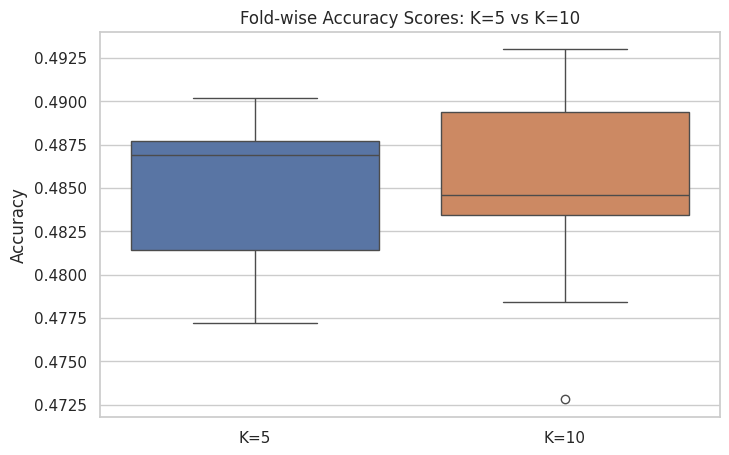

In [41]:
# Boxplot of K-Fold accuracy
accuracy_boxplot_df = pd.DataFrame({
    "K=5": pd.Series(accuracy_scores_by_k["K=5"]),
    "K=10": pd.Series(accuracy_scores_by_k["K=10"])
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=accuracy_boxplot_df)
plt.title("Fold-wise Accuracy Scores: K=5 vs K=10")
plt.ylabel("Accuracy")
plt.show()

## PART 2C. LEAVE-ONE-OUT CROSS-VALIDATION
LOOCV uses almost all data for training in every round, but it is computationally expensive because it trains the model once for every sample. For a large dataset like this, full LOOCV is not practical. LOOCV is most appropriate for small datasets where every sample is important and the computer can still finish the evaluation in a reasonable time.

In [42]:
MAX_LOOCV_ROWS = 1000

if len(X) > MAX_LOOCV_ROWS:
    print(f"Dataset has {len(X)} rows. Using {MAX_LOOCV_ROWS} rows for LOOCV to avoid extremely long execution time.")
    
    stratify_value = y if y.value_counts().min() >= 2 else None
    
    X_loo, _, y_loo, _ = train_test_split(
        X,
        y,
        train_size=MAX_LOOCV_ROWS,
        random_state=42,
        stratify=stratify_value
    )
else:
    X_loo = X
    y_loo = y

loo = LeaveOneOut()

start_time = time.time()

loo_predictions = cross_val_predict(
    model,
    X_loo,
    y_loo,
    cv=loo,
    n_jobs=-1
)

loo_execution_time = time.time() - start_time

loocv_result = {
    "Evaluation Method": f"LOOCV Sample n={len(X_loo)}",
    "Mean Accuracy": accuracy_score(y_loo, loo_predictions),
    "Mean Precision": precision_score(y_loo, loo_predictions, average="weighted", zero_division=0),
    "Mean Recall": recall_score(y_loo, loo_predictions, average="weighted", zero_division=0),
    "Mean F1-Score": f1_score(y_loo, loo_predictions, average="weighted", zero_division=0),
    "Std Deviation": np.nan,
    "Execution Time": loo_execution_time
}

loocv_df = pd.DataFrame([loocv_result])
display(loocv_df)

Dataset has 50000 rows. Using 1000 rows for LOOCV to avoid extremely long execution time.


,Evaluation Method,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score,Std Deviation,Execution Time
0,LOOCV Sample n=1000,0.471,0.448299,0.471,0.453914,NaN,17.922319


## PART 3. COMPARATIVE ANALYSIS

In [43]:
summary_df = pd.concat([holdout_df, kfold_df, loocv_df], ignore_index=True)

display(summary_df)

,Evaluation Method,Mean Accuracy,Mean Precision,Mean Recall,Mean F1-Score,Std Deviation,Execution Time
0,Holdout 70/30,0.48500,0.429515,0.48500,0.455317,NaN,0.995713
1,Holdout 80/20,0.47960,0.425061,0.47960,0.450419,NaN,1.097203
2,K-Fold CV K=5,0.48468,0.429009,0.48468,0.454921,0.004717,4.519378
3,K-Fold CV K=10,0.48492,0.429419,0.48492,0.455190,0.005757,2.892221
4,LOOCV Sample n=1000,0.47100,0.448299,0.47100,0.453914,NaN,17.922319


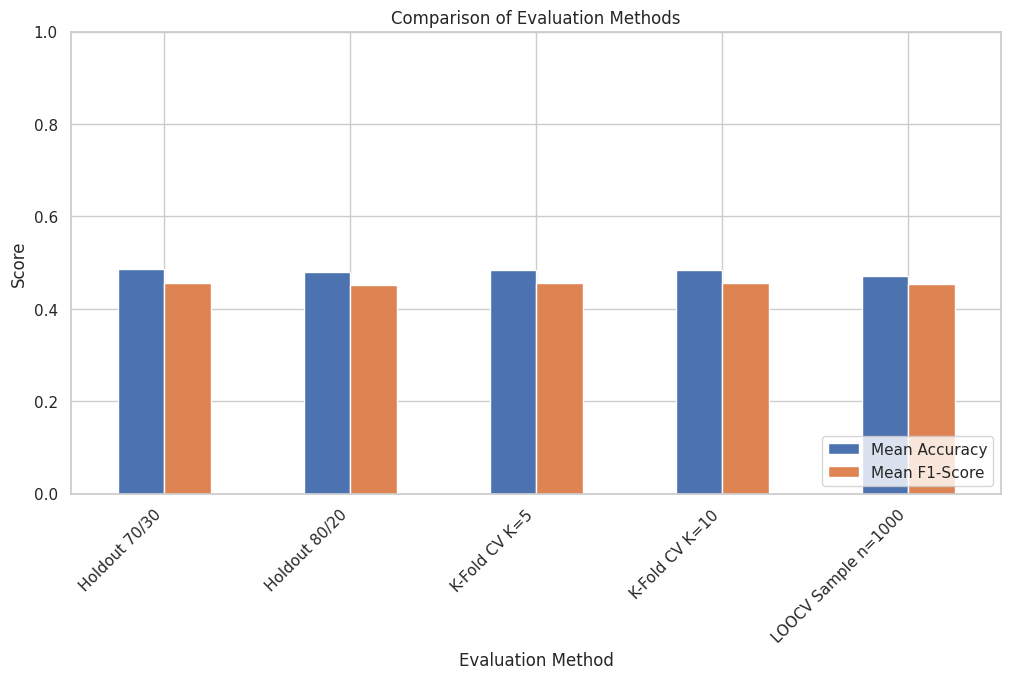

In [44]:
# GROUP BAR CHART
summary_plot = summary_df.set_index("Evaluation Method")[["Mean Accuracy", "Mean F1-Score"]]

summary_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Comparison of Evaluation Methods")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

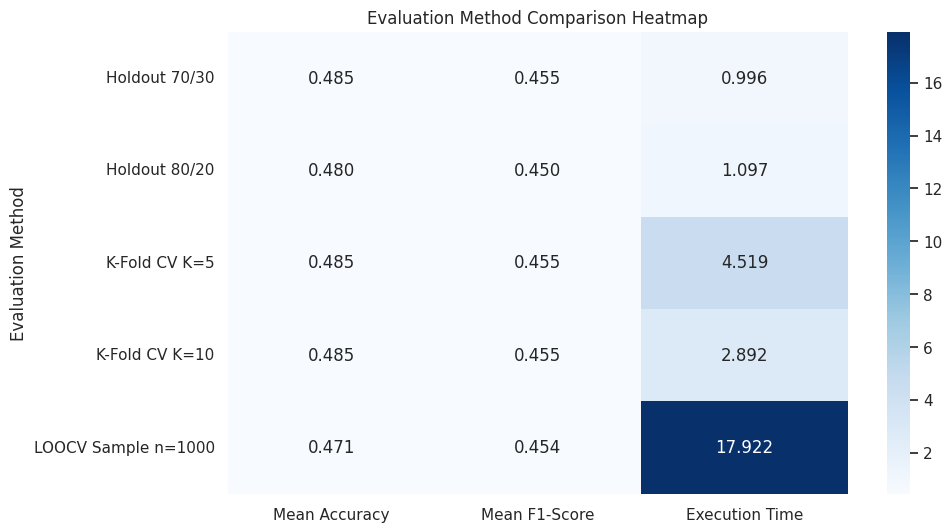

In [45]:
# HEATMAP
plt.figure(figsize=(10, 6))
sns.heatmap(
    summary_df.set_index("Evaluation Method")[["Mean Accuracy", "Mean F1-Score", "Execution Time"]],
    annot=True,
    fmt=".3f",
    cmap="Blues"
)
plt.title("Evaluation Method Comparison Heatmap")
plt.show()

If the dataset had only 50 samples, I would recommend LOOCV or K-Fold Cross-Validation because a simple holdout split would waste too much data for testing. LOOCV is useful for very small datasets because it trains on almost all available samples.

If the dataset had 500,000 samples, I would recommend Holdout or 5-Fold Cross-Validation because LOOCV would be too slow. With a very large dataset, a holdout split can already give a reliable estimate because the test set is large enough.

## PART 4. CRITICAL THINKING QUESTIONS

#### 1. A classmate argues that accuracy alone is sufficient to evaluate a medical classifier. Do you agree? Construct a counterexample using the Recall metric to support your argument.

I do not agree that accuracy alone is sufficient. For example, imagine a disease detection model where 95 out of 100 patients are healthy and 5 actually have the disease. If the model predicts every patient as healthy, it will achieve 95% accuracy, which looks very high. However, it will fail to detect all 5 sick patients. In this case, the Recall for the diseased class would be 0%, because none of the actual positive cases were identified.

This shows that accuracy can be misleading, especially in sensitive applications like healthcare. Recall is important because it measures how many actual positive cases the model successfully finds. In medical classification, missing a true positive can have serious consequences, so Recall is often more meaningful than Accuracy alone.


#### 2. Your model achieves 95% accuracy but the dataset is 95% Class A and 5% Class B. Is this model trustworthy? What would you do differently

This model is not automatically trustworthy. If the dataset is highly imbalanced, a model can reach 95% accuracy simply by predicting every sample as Class A. That means it may completely ignore Class B, which could be the more important class.

To evaluate the model properly, I would look at Precision, Recall, and F1-Score for each class, especially the minority class. I would also check the confusion matrix to see whether the model is actually identifying Class B. If the minority class is important, I would consider using stratified sampling, class weighting, resampling methods, or other techniques to address class imbalance.

#### 3. Explain why shuffling data before K-Fold splitting matters. What problem could arise if you apply K-Fold on time-series data without shuffling?

Shuffling matters because it helps distribute the samples more evenly across the folds. If the data is ordered by class, time, or some other structure, then some folds may contain only certain types of observations, which can lead to biased or unstable results.

However, for time-series data, shuffling can be a problem because it breaks the natural time order. If future information is mixed into the training set while earlier observations are in the test set, the model may appear better than it really is. This is called data leakage. For time-series problems, it is better to use time-aware validation methods rather than standard shuffled K-Fold.


#### 4. If you had to present this model's performance to an administrator who is not a data scientist, which single metric would you highlight and how would you explain it?

If I had to explain the model to an administrator, I would highlight the **F1-Score**. I would explain that F1-Score gives a balanced view of performance because it considers both how often the model is correct when it makes a positive prediction and how often it successfully detects the actual positive cases.

I would describe it in simple terms by saying that F1-Score helps show whether the model is both accurate and dependable, especially when the classes are not perfectly balanced. This makes it more informative than accuracy alone in many real-world situations.

## CONCLUSIONS

Based on the results of our experiment using **`major_category` as the target variable**, our group concludes that **K-Fold Cross-Validation with K=10** is the most appropriate evaluation method for this dataset. Although the Accuracy and F1-Score values across the different methods are very close, **K-Fold CV with K=10** gives a strong balance between performance reliability and computational efficiency. It achieved one of the highest mean accuracy scores and maintained the same strong F1-Score as the other top-performing methods, which shows that the model performs consistently across multiple folds rather than depending on only one train-test split.

We do not recommend relying only on the Holdout Method, even if its scores are also competitive, because it evaluates the model using only one data split, which can make the result less stable. On the other hand, **LOOCV** produced a slightly lower accuracy and required the **highest execution time**, making it the least practical option for this dataset. Therefore, our group recommends **K-Fold CV with K=10** because it provides a more dependable estimate of model performance than Holdout while being much more practical than LOOCV in terms of computation time.